Sube el archivo 'ResistMangos.csv'


Saving ResistMangos.csv to ResistMangos (5).csv

Tipo de prueba disponible:
 - 'min' → detectar si el valor más pequeño es un atípico
 - 'max' → detectar si el valor más grande es un atípico
 - 'bilateral' → detectar el valor más extremo (mínimo o máximo)

Ingresa el tipo de prueba ('min', 'max', 'bilateral'): min

--- Resultados de la Prueba de Grubbs ---
Tipo de prueba: MIN
N: 14
Media: 123.37
Desviación estándar: 46.29
Valor sospechoso: 12.38 (fila 10)
G: 2.40
G crítico: 2.37
p-valor: 0.031

✅ El valor 12.38 en la fila 10 es un valor atípico (p < 0.05)


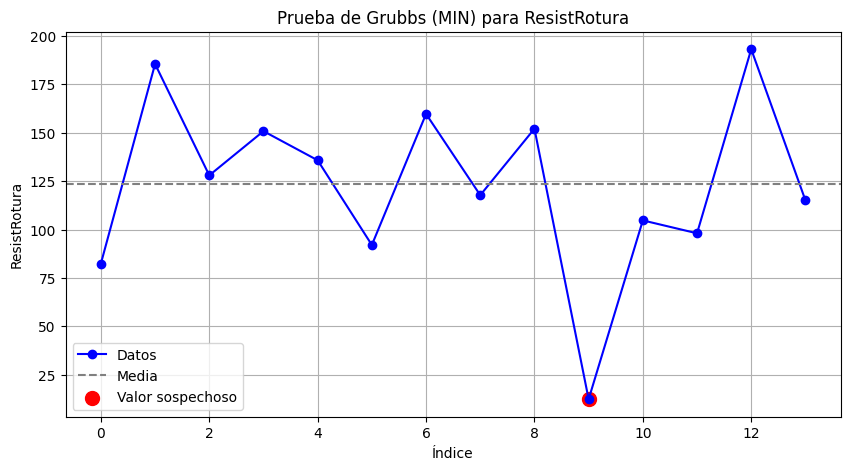

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import files

# Subida del archivo CSV
print("Sube el archivo 'ResistMangos.csv'")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Selección de la columna
col = 'ResistRotura'
data = df[col].dropna().reset_index(drop=True)
n = len(data)
mean = data.mean()
std = data.std(ddof=1)

# Elegir tipo de prueba
print("\nTipo de prueba disponible:")
print(" - 'min' → detectar si el valor más pequeño es un atípico")
print(" - 'max' → detectar si el valor más grande es un atípico")
print(" - 'bilateral' → detectar el valor más extremo (mínimo o máximo)")

tipo_prueba = input("\nIngresa el tipo de prueba ('min', 'max', 'bilateral'): ").strip().lower()
alpha = 0.05

# Cálculo de G según el tipo de prueba
if tipo_prueba == 'min':
    x_out = data.min()
    G = (mean - x_out) / std
    out_idx = data.idxmin()
    p_direccion = alpha / n
elif tipo_prueba == 'max':
    x_out = data.max()
    G = (x_out - mean) / std
    out_idx = data.idxmax()
    p_direccion = alpha / n
elif tipo_prueba == 'bilateral':
    diff = abs(data - mean)
    x_out = data.iloc[diff.idxmax()]
    G = diff.max() / std
    out_idx = diff.idxmax()
    p_direccion = alpha / (2 * n)
else:
    raise ValueError("Tipo de prueba no válido. Usa: 'min', 'max' o 'bilateral'.")

# Cálculo de G crítico
t_crit = stats.t.ppf(1 - p_direccion, df=n - 2)
G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))

# Cálculo de p-valor
numerador = (G * np.sqrt(n - 1)) / np.sqrt(n - 2 + G**2)
if tipo_prueba == 'bilateral':
    p_val = 2 * (1 - stats.t.cdf(numerador, df=n - 2))
else:
    p_val = 1 - stats.t.cdf(numerador, df=n - 2)

# Resultados
print("\n--- Resultados de la Prueba de Grubbs ---")
print(f"Tipo de prueba: {tipo_prueba.upper()}")
print(f"N: {n}")
print(f"Media: {mean:.2f}")
print(f"Desviación estándar: {std:.2f}")
print(f"Valor sospechoso: {x_out} (fila {out_idx + 1})")
print(f"G: {G:.2f}")
print(f"G crítico: {G_crit:.2f}")
print(f"p-valor: {p_val:.3f}")

if G > G_crit:
    print(f"\n✅ El valor {x_out} en la fila {out_idx + 1} es un valor atípico (p < {alpha})")
else:
    print("\n❌ No se detectaron valores atípicos según Grubbs.")

# Visualización
plt.figure(figsize=(10, 5))
plt.plot(data.values, 'bo-', label='Datos')
plt.axhline(mean, linestyle='--', color='gray', label='Media')
plt.scatter(out_idx, x_out, color='red', s=100, label='Valor sospechoso')
plt.title(f'Prueba de Grubbs ({tipo_prueba.upper()}) para {col}')
plt.xlabel("Índice")
plt.ylabel(col)
plt.legend()
plt.grid(True)
plt.show()

